In [46]:
!pip install nbconvert

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pandas.api.types import CategoricalDtype
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, \
recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

### <b> Step 1) Loading all my data in seperate dataframes and organising them </b>

In [2]:
df_nvda=pd.read_csv("NVDAraw.csv")

### <b>Step 2) Data Cleaning </b>

In [3]:
df_nvda.head() # details about my data , that I will utilsie furhter for data cleaning and wrangling 

,Date,Price,Open,High,Low,Vol.,Change %
0,03/05/2025,114.95,117.54,117.98,114.68,109.81M,-0.90%
1,03/04/2025,115.99,110.65,119.31,110.11,398.16M,1.69%
2,03/03/2025,114.06,123.51,123.70,112.28,411.38M,-8.69%
3,02/28/2025,124.92,118.02,125.09,116.40,389.09M,3.97%
4,02/27/2025,120.15,135.00,135.01,120.01,443.18M,-8.48%


In [4]:
df_nvda.shape # to determine the total shape(rows x columns) after my dataset has been merged into one 

(1257, 7)

In [5]:
df_nvda.columns
#to get to know about the columns that are now present in my data 

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')

In [6]:
df_nvda.dtypes
#from this i will now convert vol and and into floats as well in all my data sets so that my data is mathematically processible. 
# following this, I will convert the Date into Datetime format from string format 

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.         object
Change %     object
dtype: object

In [7]:
df_nvda.info() #to check for any null values in my data to be cleaned. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1257 non-null   object 
 1   Price     1257 non-null   float64
 2   Open      1257 non-null   float64
 3   High      1257 non-null   float64
 4   Low       1257 non-null   float64
 5   Vol.      1257 non-null   object 
 6   Change %  1257 non-null   object 
dtypes: float64(4), object(3)
memory usage: 68.9+ KB


In [47]:
df_nvda['Vol.'].max() #the highest value in Val. column is in Millions , to be used in the next slide 
df_nvda['Vol.'].min()

97880000.0

<b>2.1</b>: Removing the string at the end of the "Vol." column and adding the relevant number of zero's next to it to main data authenticity. 


In [9]:
def convert_volume(val):
    val = str(val).lower()
    if 'm' in val:
        return float(val.replace('m', '')) * 1_000_000
    elif 'k' in val:
        return float(val.replace('k', '')) * 1_000 
    elif 'b'  in val:
        return float(val.replace('b', '')) * 1_000_000_000
    return float(val)


df_nvda['Vol.'] = df_nvda['Vol.'].apply(convert_volume)
df_nvda

,Date,Price,Open,High,Low,Vol.,Change %
0,03/05/2025,114.95,117.54,117.98,114.68,109810000.0,-0.90%
1,03/04/2025,115.99,110.65,119.31,110.11,398160000.0,1.69%
2,03/03/2025,114.06,123.51,123.70,112.28,411380000.0,-8.69%
3,02/28/2025,124.92,118.02,125.09,116.40,389090000.0,3.97%
4,02/27/2025,120.15,135.00,135.01,120.01,443180000.0,-8.48%
...,...,...,...,...,...,...,...
1252,03/11/2020,6.16,6.39,6.42,6.06,502070000.0,-5.67%
1253,03/10/2020,6.53,6.41,6.53,6.15,580650000.0,6.35%
1254,03/09/2020,6.14,6.00,6.49,5.95,614160000.0,-7.67%
1255,03/06/2020,6.65,6.65,6.71,6.45,515410000.0,-2.64%


In [10]:
df_nvda.dtypes

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object

<b>2.2</b>: Now removing the percentage sign at the end of change in all rows. 

In [11]:

df_nvda["Change %"]=df_nvda["Change %"].str.removesuffix("%") #removing the percentage sign at the end of all column values for percentage change 

# now converting  its data type from object to float:

print('Change %  was dtype: {}'.format(df_nvda['Change %'].dtype))
df_nvda= df_nvda.astype({'Change %': float}) 
print('Change % is now dtype: {}' .format(df_nvda['Change %'].dtype))

#The result:
df_nvda

Change %  was dtype: object
Change % is now dtype: float64


,Date,Price,Open,High,Low,Vol.,Change %
0,03/05/2025,114.95,117.54,117.98,114.68,109810000.0,-0.90
1,03/04/2025,115.99,110.65,119.31,110.11,398160000.0,1.69
2,03/03/2025,114.06,123.51,123.70,112.28,411380000.0,-8.69
3,02/28/2025,124.92,118.02,125.09,116.40,389090000.0,3.97
4,02/27/2025,120.15,135.00,135.01,120.01,443180000.0,-8.48
...,...,...,...,...,...,...,...
1252,03/11/2020,6.16,6.39,6.42,6.06,502070000.0,-5.67
1253,03/10/2020,6.53,6.41,6.53,6.15,580650000.0,6.35
1254,03/09/2020,6.14,6.00,6.49,5.95,614160000.0,-7.67
1255,03/06/2020,6.65,6.65,6.71,6.45,515410000.0,-2.64


<b>2.3</b>: Now converting Date column from string format to Datetime format 

In [12]:
#re-arranging it in the YYYY-MM-DD format from MM/DD/YYYY
df_nvda["Date"]=pd.to_datetime(df_nvda["Date"] , format="%m/%d/%Y")
df_nvda = df_nvda.sort_values(by="Date", ascending=True).reset_index(drop=True)
df_nvda

,Date,Price,Open,High,Low,Vol.,Change %
0,2020-03-05,6.83,6.91,7.08,6.79,540330000.0,-3.94
1,2020-03-06,6.65,6.65,6.71,6.45,515410000.0,-2.64
2,2020-03-09,6.14,6.00,6.49,5.95,614160000.0,-7.67
3,2020-03-10,6.53,6.41,6.53,6.15,580650000.0,6.35
4,2020-03-11,6.16,6.39,6.42,6.06,502070000.0,-5.67
...,...,...,...,...,...,...,...
1252,2025-02-27,120.15,135.00,135.01,120.01,443180000.0,-8.48
1253,2025-02-28,124.92,118.02,125.09,116.40,389090000.0,3.97
1254,2025-03-03,114.06,123.51,123.70,112.28,411380000.0,-8.69
1255,2025-03-04,115.99,110.65,119.31,110.11,398160000.0,1.69


In [13]:
#Hence, proven: 
df_nvda.dtypes

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object

<b>2.4</b> : Checking for null values in all data frames 

In [14]:
df_nvda.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [15]:
# Verifying the data set to spot any outliers. Mostly analysing the count to see if it is the same as above, min and max to see if they are logical and not boundary values. 
df_nvda.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,1257,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03,1257.000000
mean,2022-09-01 10:01:25.918854400,42.685338,42.711830,43.501098,41.814200,4.404561e+08,0.280390
min,2020-03-05 00:00:00,4.910000,5.000000,5.250000,4.520000,9.788000e+07,-18.440000
25%,2021-06-03 00:00:00,14.250000,14.180000,14.410000,13.910000,3.025800e+08,-1.660000
50%,2022-08-31 00:00:00,22.440000,22.500000,22.880000,22.050000,4.167800e+08,0.310000
75%,2023-11-30 00:00:00,48.330000,48.390000,49.080000,47.690000,5.424400e+08,2.270000
max,2025-03-05 00:00:00,149.430000,153.030000,153.130000,147.820000,1.540000e+09,24.370000
std,NaN,41.279099,41.383555,42.097785,40.451288,1.850878e+08,3.441157


In [16]:
print(df_nvda.columns)

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')


In [17]:
df_nvda.dtypes
#confirming data types 

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object

In [18]:
df_nvda["Change %"].unique() #checking for unique values in my columns

#no unique values in any of my columns. 

array([-3.940e+00, -2.640e+00, -7.670e+00,  6.350e+00, -5.670e+00,
       -1.218e+01,  1.128e+01, -1.844e+01,  1.059e+01, -6.630e+00,
        4.930e+00, -3.380e+00,  3.500e+00,  1.711e+01, -1.440e+00,
        4.720e+00, -1.710e+00,  5.060e+00, -7.500e-01, -7.740e+00,
        5.100e+00, -4.540e+00,  1.000e+01, -3.430e+00,  2.930e+00,
       -1.500e+00,  2.740e+00,  5.190e+00, -1.130e+00,  4.990e+00,
       -8.100e-01, -1.780e+00, -6.130e+00,  6.080e+00, -7.000e-01,
        1.970e+00,  2.620e+00, -2.020e+00,  2.470e+00, -2.010e+00,
       -3.280e+00,  2.970e+00,  8.200e-01,  1.360e+00,  2.420e+00,
        2.490e+00,  3.330e+00, -3.350e+00, -2.600e-01,  3.210e+00,
        5.730e+00,  3.060e+00,  6.900e-01,  1.820e+00, -2.120e+00,
        2.850e+00, -2.180e+00, -4.700e-01,  4.590e+00, -7.900e-01,
        2.300e-01, -6.800e-01,  0.000e+00,  1.710e+00, -1.350e+00,
        2.840e+00,  3.540e+00, -6.080e+00,  1.480e+00,  2.690e+00,
       -1.090e+00,  1.870e+00, -2.200e-01,  4.300e-01,  2.920e

In [19]:
#– how skewed is data? = it is completely aligned 
#– any bias in the data? = All my data is coherent and under reasonable values when check from df_all_stocks.describe()

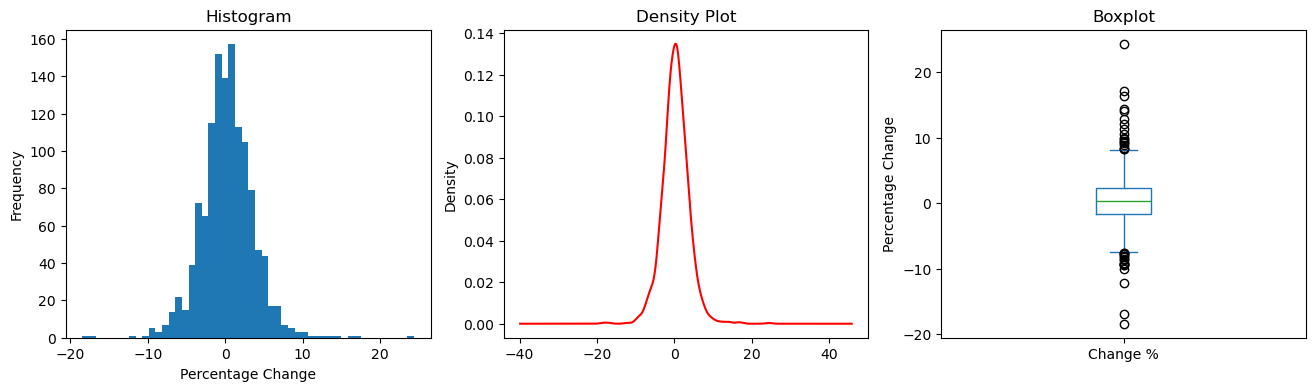

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
df_nvda['Change %'].plot(kind='hist', bins=50, ax=axes[0], xlabel="Percentage Change", title="Histogram")

df_nvda['Change %'].plot(kind='density', color='r', ax=axes[1], title='Density Plot')
df_nvda['Change %'].plot(kind='box', ax=axes[2], ylabel='Percentage Change', xlabel='', title='Boxplot')
plt.show()

### <b> Step 3) Bivariate analysis </b>

Analysing the relationship between an existing feature and Target_Direction

In [21]:
#Creating a modelling dataframe to run experiments on this without disrupting the main data frame as a good practice. 

df_nvda_copy = df_nvda.copy()

print(df_nvda_copy.shape)
df_nvda_copy.head()

(1257, 7)


,Date,Price,Open,High,Low,Vol.,Change %
0,2020-03-05,6.83,6.91,7.08,6.79,540330000.0,-3.94
1,2020-03-06,6.65,6.65,6.71,6.45,515410000.0,-2.64
2,2020-03-09,6.14,6.00,6.49,5.95,614160000.0,-7.67
3,2020-03-10,6.53,6.41,6.53,6.15,580650000.0,6.35
4,2020-03-11,6.16,6.39,6.42,6.06,502070000.0,-5.67


<b>3.1 Bivariate Analysis for days of the week predicting the next day increase or decrease in share price </b>
This takes into account calendar seasonality , how different days effect normal trading patterns assuming all goes well during the week ceteris paribus. 

Target_Direction
1    668
0    568
Name: count, dtype: int64
Target_Direction
1    0.5405
0    0.4595
Name: proportion, dtype: float64


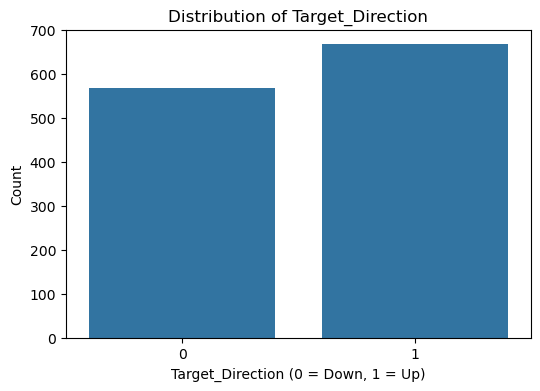

Percentage Breakdown by Day of the Week:
Target_Direction      0      1
Day_of_Week                   
Friday            39.92  60.08
Monday            48.47  51.53
Thursday          50.80  49.20
Tuesday           47.06  52.94
Wednesday         43.70  56.30


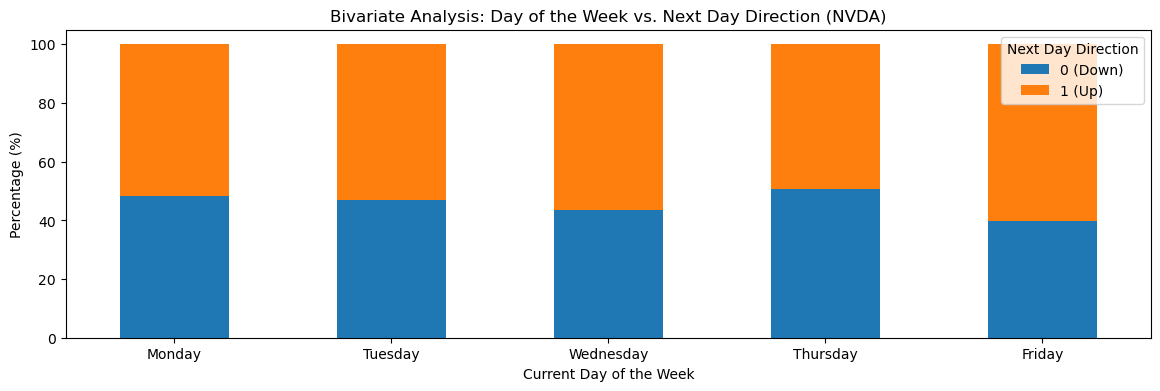

In [45]:
# creating a new categorical variable here i.e. " Day of the week " so that we can analyse weekly performance between specific days. 
df_nvda_copy['Day_of_Week'] = df_nvda_copy['Date'].dt.day_name()
# define next day's close
df_nvda_copy["Next_Close"] = df_nvda_copy["Price"].shift(-1)

# target: 1 if next day's close is higher than today's close, else 0
df_nvda_copy["Target_Direction"] = np.where(df_nvda_copy["Next_Close"] > df_nvda_copy["Price"], 1, 0)

# remove final row because there is no next-day label
df_nvda_copy = df_nvda_copy.iloc[:-1].copy()

# target balance
print(df_nvda_copy["Target_Direction"].value_counts())
print(df_nvda_copy["Target_Direction"].value_counts(normalize=True).round(4))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_nvda_copy, x="Target_Direction")
plt.title("Distribution of Target_Direction")
plt.xlabel("Target_Direction (0 = Down, 1 = Up)")
plt.ylabel("Count")
plt.show()

day_crosstab = pd.crosstab(df_nvda_copy['Day_of_Week'], df_nvda_copy["Target_Direction"], normalize='index') * 100

print("Percentage Breakdown by Day of the Week:")
print(day_crosstab.round(2))
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
day_crosstab = day_crosstab.reindex(ordered_days)
df_nvda_copy

#Plotting the Bivariate Analysis for step 3.1 

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 4))
day_crosstab.plot(kind="bar",
                  stacked=True,
                  ax=ax ,
                  title= 'Bivariate Analysis: Day of the Week vs. Next Day Direction (NVDA)', 
                  xlabel='Current Day of the Week',
                  ylabel='Percentage (%)')
plt.legend(title='Next Day Direction', labels=['0 (Down)', '1 (Up)'])
plt.xticks(rotation=0)
plt.show()

Useful Analysis, I can see variation in this.All days of the week except for Thursday have an increase in their next day prices

<b> 3.2(a) Bear Trend - to check if the price is below the 20 day average as a part of my exploratory data analysis 

<class 'pandas.core.frame.DataFrame'>
Index: 1237 entries, 19 to 1255
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1237 non-null   datetime64[ns]
 1   Price             1237 non-null   float64       
 2   Open              1237 non-null   float64       
 3   High              1237 non-null   float64       
 4   Low               1237 non-null   float64       
 5   Vol.              1237 non-null   float64       
 6   Change %          1237 non-null   float64       
 7   Day_of_Week       1237 non-null   object        
 8   Next_Close        1237 non-null   float64       
 9   Target_Direction  1237 non-null   int64         
 10  20_Day_MA         1237 non-null   float64       
 11  Bear_Trend        1237 non-null   int64         
dtypes: datetime64[ns](1), float64(8), int64(2), object(1)
memory usage: 125.6+ KB
Percentage Breakdown by Market Trend:
Target_Direction    

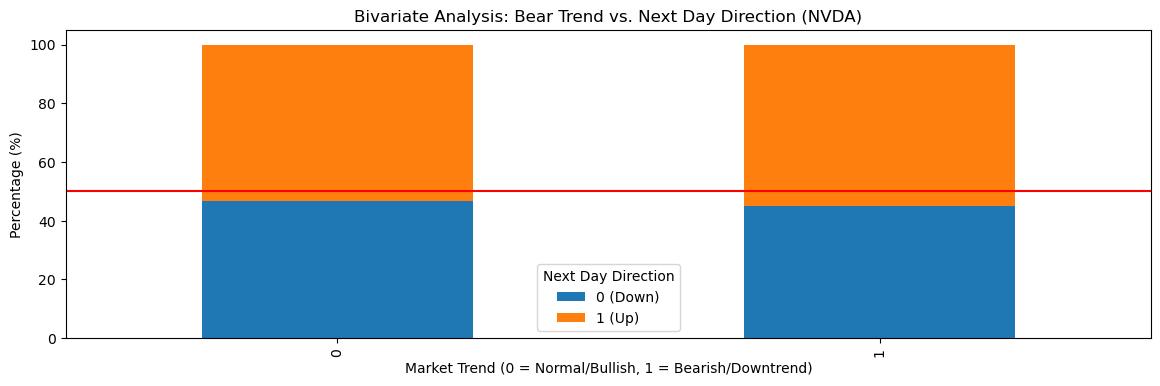

In [23]:
df_nvda_copy['20_Day_MA'] = df_nvda_copy['Price'].rolling(window=20).mean()
df_nvda_copy.isnull().sum()
#Results in 19 null values in the 20 day moving average.
# # The 20-Day Moving Average requires 20 days of history, which naturally creates  19 Null (NaN) values at 
# the very start of the dataset. Will drop these NaN values to maintain accuracy 
# of the dataset and because they will not have an effect on the performance of the data set positively. 
trend_df = df_nvda_copy.dropna(subset=["20_Day_MA", "Target_Direction"]).copy()
trend_df['Bear_Trend'] = np.where(trend_df['Price'] < trend_df['20_Day_MA'], 1, 0)
trend_df.info()


#Target direction comparison with market trends 
bear_crosstab = pd.crosstab(trend_df['Bear_Trend'], trend_df['Target_Direction'], normalize='index') * 100
print("Percentage Breakdown by Market Trend:")
print(bear_crosstab.round(2))


#plotting the graph

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 4))
bear_crosstab.plot(kind='bar',
                   stacked=True,
                   ax=ax,
                   xlabel='Market Trend (0 = Normal/Bullish, 1 = Bearish/Downtrend)',
                   ylabel='Percentage (%)',
                   title=('Bivariate Analysis: Bear Trend vs. Next Day Direction (NVDA)'))
plt.legend(title='Next Day Direction', labels=['0 (Down)', '1 (Up)'])
plt.axhline(50, color='red', linestyle='-', label='50% Baseline')
plt.show()

The Bivariate Analysis tells us that there is a very minor change in the Bear Trend. When the stock dips into a Bear Trend (1), aggressive market buying pushes  the probability of it going UP the next day to 55.1%, which is higher than its normal upward baseline of 53.5%.

<b> 3.3 Intraday Volatility (Wild vs. Calm Days) </b>

Utilisng the High and Low column, we will analyse if the High and Low are very far apart, the stock had a volatile day. If they are close together, the stock was calm. Does a volatile day predict that tomorrow will be a Down day? 

Target_Direction
0    3.965
1    4.002
Name: Intraday_Return_Pct, dtype: float64


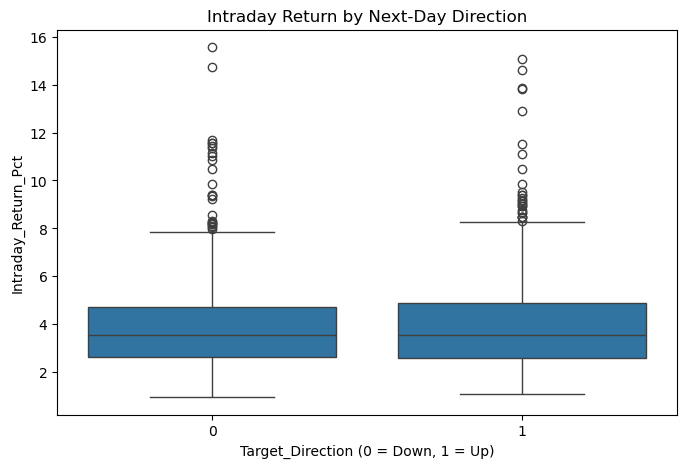

In [24]:
#creating a variable for intraday volatality
#df_nvda_copy["Intraday_Return_Pct"] = ((df_nvda_copy["Price"] - df_nvda_copy["Open"]) / df_nvda_copy["Open"]) * 100
df_nvda_copy["Intraday_Return_Pct"] = ((df_nvda_copy["High"] - df_nvda_copy["Low"]) / df_nvda_copy["Open"]) * 100
print(df_nvda_copy.groupby("Target_Direction")["Intraday_Return_Pct"].mean().round(3))

#plotting a box plot for better accuracy 
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_nvda_copy, x="Target_Direction", y="Intraday_Return_Pct")
plt.title("Intraday Return by Next-Day Direction")
plt.xlabel("Target_Direction (0 = Down, 1 = Up)")
plt.ylabel("Intraday_Return_Pct")
plt.show()



Intraday volatility is a poor predictor of next-day direction. Whether the stock has a calm day or a wild swing the target direction remains mildly effected 


### <b> Step 4: Feature Engineering </b>

In [25]:

# (a) Day-to-day percentage change in volume
df_nvda_copy["Volume_Change_Pct"] = df_nvda_copy["Vol."].pct_change() * 100

#(b)  Previous day's direction
df_nvda_copy["Prev_Direction_1"] = np.where(df_nvda_copy["Change %"].shift(1) > 0, 1, 0)

# (c) Price relative to moving average
df_nvda_copy["Price_vs_20_Day_MA_Pct"] = ((df_nvda_copy["Price"] - df_nvda_copy["20_Day_MA"]) / df_nvda_copy["20_Day_MA"]) * 100

# (d) 5-day rolling volatility of daily % change
df_nvda_copy["Volatility_5D"] = df_nvda_copy["Change %"].rolling(window=5).std()


df_nvda_copy.head(50)

,Date,Price,Open,High,Low,Vol.,Change %,Day_of_Week,Next_Close,Target_Direction,20_Day_MA,Intraday_Return_Pct,Volume_Change_Pct,Prev_Direction_1,Price_vs_20_Day_MA_Pct,Volatility_5D
0,2020-03-05,6.83,6.91,7.08,6.79,5.403300e+08,-3.94,Thursday,6.65,0,NaN,4.196816,NaN,0,NaN,NaN
1,2020-03-06,6.65,6.65,6.71,6.45,5.154100e+08,-2.64,Friday,6.14,0,NaN,3.909774,-4.611996,0,NaN,NaN
2,2020-03-09,6.14,6.00,6.49,5.95,6.141600e+08,-7.67,Monday,6.53,1,NaN,9.000000,19.159504,0,NaN,NaN
3,2020-03-10,6.53,6.41,6.53,6.15,5.806500e+08,6.35,Tuesday,6.16,0,NaN,5.928237,-5.456233,0,NaN,NaN
4,2020-03-11,6.16,6.39,6.42,6.06,5.020700e+08,-5.67,Wednesday,5.41,0,NaN,5.633803,-13.533109,1,NaN,5.407507
5,2020-03-12,5.41,5.64,5.90,5.39,8.165400e+08,-12.18,Thursday,6.02,1,NaN,9.042553,62.634692,0,NaN,6.918943
6,2020-03-13,6.02,5.76,6.03,5.49,6.348400e+08,11.28,Friday,4.91,0,NaN,9.375000,-22.252431,0,NaN,9.930265
7,2020-03-16,4.91,5.31,5.65,4.85,7.269700e+08,-18.44,Monday,5.43,1,NaN,15.065913,14.512318,1,NaN,12.434395
8,2020-03-17,5.43,5.02,5.52,4.78,8.336300e+08,10.59,Tuesday,5.07,0,NaN,14.741036,14.671857,0,NaN,13.400878
9,2020-03-18,5.07,5.00,5.25,4.52,8.742700e+08,-6.63,Wednesday,5.32,1,NaN,14.600000,4.875064,1,NaN,13.457531


### <b> Step 5: Model Preparation </b>

Step 5.1: Dropping the missing values created by the new rolling averages :


In [26]:
print("Before dropna:", df_nvda_copy.shape)

df_nvda_copy = df_nvda_copy.dropna(subset=[
    "Volume_Change_Pct",
    "Intraday_Return_Pct",
    "Prev_Direction_1",
    "20_Day_MA",
    "Price_vs_20_Day_MA_Pct",
    "Volatility_5D",
    "Target_Direction"
]).copy()

print("After dropna:", df_nvda_copy.shape)
df_nvda_copy.head()

Before dropna: (1256, 16)
After dropna: (1237, 16)


,Date,Price,Open,High,Low,Vol.,Change %,Day_of_Week,Next_Close,Target_Direction,20_Day_MA,Intraday_Return_Pct,Volume_Change_Pct,Prev_Direction_1,Price_vs_20_Day_MA_Pct,Volatility_5D
19,2020-04-01,6.08,6.39,6.54,6.03,656910000.0,-7.74,Wednesday,6.39,1,5.9680,7.981221,-30.848667,0,1.876676,5.273541
20,2020-04-02,6.39,6.11,6.40,6.06,675760000.0,5.10,Thursday,6.10,0,5.9460,5.564648,2.869495,0,7.467205,5.362077
21,2020-04-03,6.10,6.35,6.39,5.96,663210000.0,-4.54,Friday,6.71,1,5.9185,6.771654,-1.857168,1,3.066655,5.723808
22,2020-04-06,6.71,6.38,6.75,6.32,727880000.0,10.00,Monday,6.48,0,5.9470,6.739812,9.751059,0,12.829998,7.180437
23,2020-04-07,6.48,6.93,6.96,6.43,784520000.0,-3.43,Tuesday,6.67,1,5.9445,7.647908,7.781502,1,9.008327,7.386130


Step 5.2 : Changing Categorical Variables to integer ones 

Most of my variables are integeres except of the "day of the week" column that I created in step 3.1. I will now be converting it into a categorical variable

In [27]:
my_custom_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

In [28]:
cat_type = CategoricalDtype(categories=my_custom_order, ordered=True)
df_nvda_copy['Day_of_Week'] = df_nvda_copy['Day_of_Week'].astype(cat_type)
df_nvda_copy['Day_of_Week_Binary'] = df_nvda_copy['Day_of_Week'].cat.codes
check_df = df_nvda_copy[['Day_of_Week', 'Day_of_Week_Binary']].drop_duplicates().sort_values('Day_of_Week_Binary')
print("Proof of the new .cat.codes mapping:\n")
print(check_df.to_string(index=False))

Proof of the new .cat.codes mapping:

Day_of_Week  Day_of_Week_Binary
     Monday                   0
    Tuesday                   1
  Wednesday                   2
   Thursday                   3
     Friday                   4


<b> Step 6: Feature Selection 

6.1 Analysing correlations between each pair of variables using Pandas

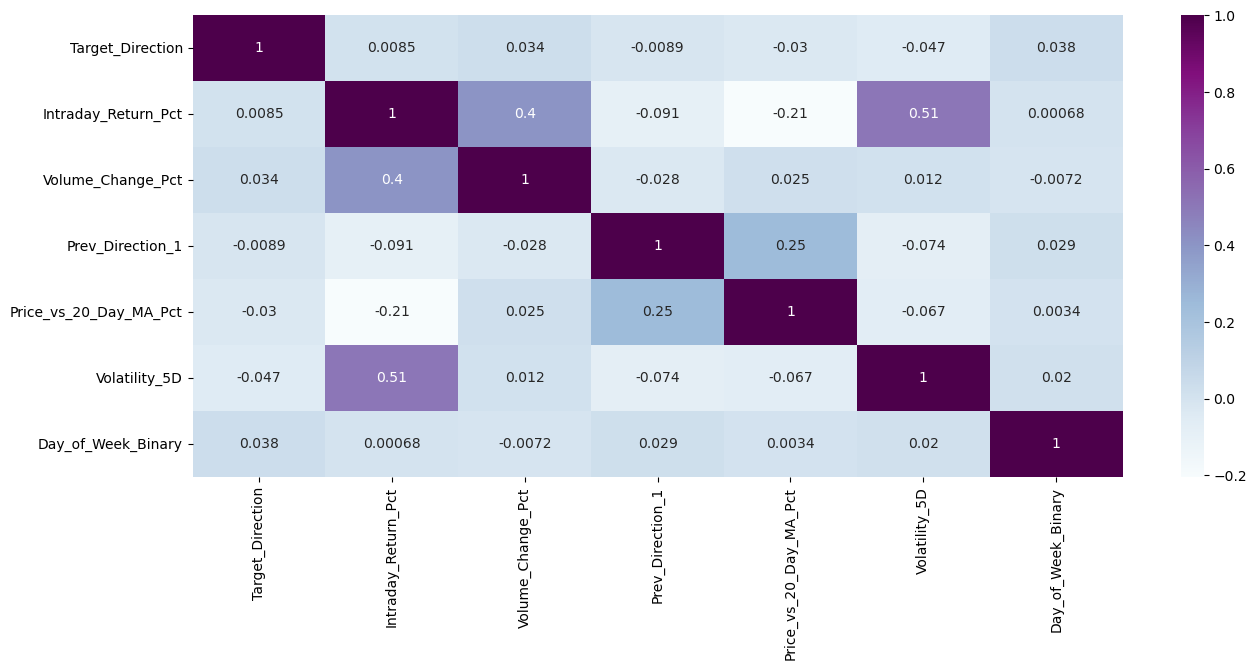

In [30]:
corr_cols = [
    "Target_Direction",
    "Intraday_Return_Pct",
    "Volume_Change_Pct",
    "Prev_Direction_1",
    "Price_vs_20_Day_MA_Pct",
    "Volatility_5D",
    "Day_of_Week_Binary"]   # for Day_of_Week_Code if that is  the numeric version for days of the week

corr=df_nvda_copy[corr_cols].corr() # gives us the correlation values
plt.figure(figsize=(15,6))
sns.heatmap(corr, annot = True, cmap="BuPu") 
plt.show()



Conclusion- No single feature has a strong linear relationship with next-day direction. However, this is normal for the volatile nature of stock data. Among the predictors themselves, the biggest correlations are:

- Intraday_Return_Pct and Volatility_5D = 0.51
- Intraday_Return_Pct and Volume_Change_Pct = 0.40
- Prev_Direction_1 and Price_vs_20_Day_MA_Pct = 0.25

These are moderate, not extreme and can be worked with. 

 6.2: Analysing  how strongly the remaining feature variables are associated with
the target variable using Scikit-learn

X shape: (1237, 6)
y shape: (1237,)


,Intraday_Return_Pct,Volume_Change_Pct,Prev_Direction_1,Price_vs_20_Day_MA_Pct,Volatility_5D,Day_of_Week_Binary
19,7.981221,-30.848667,0,1.876676,5.273541,2
20,5.564648,2.869495,0,7.467205,5.362077,3
21,6.771654,-1.857168,1,3.066655,5.723808,4
22,6.739812,9.751059,0,12.829998,7.180437,0
23,7.647908,7.781502,1,9.008327,7.386130,1


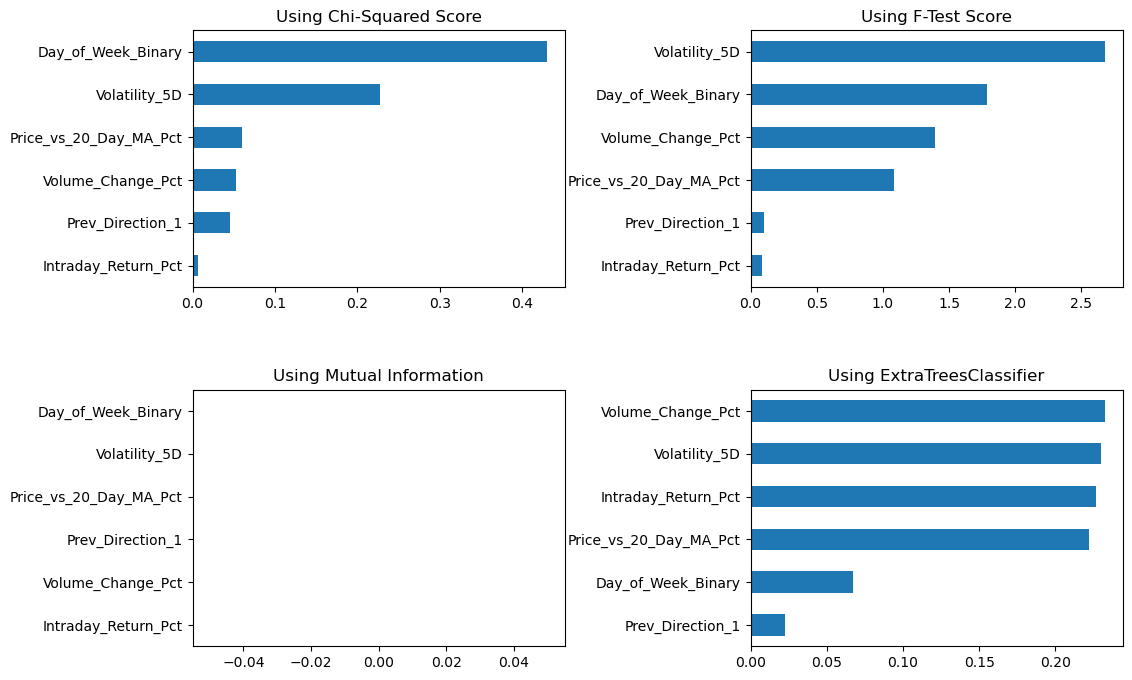

Feature association summary:


,Chi2,F_Test,Mutual_Info,ExtraTrees_Importance
Day_of_Week_Binary,0.429954,1.785665,0,0.066955
Intraday_Return_Pct,0.007136,0.088282,0,0.226529
Prev_Direction_1,0.044942,0.097554,0,0.022476
Price_vs_20_Day_MA_Pct,0.059481,1.081028,0,0.221929
Volatility_5D,0.226825,2.677209,0,0.229619
Volume_Change_Pct,0.053047,1.391792,0,0.232492


In [31]:

# Use the exact weekday column you currently have

feature_cols = [
    "Intraday_Return_Pct",
    "Volume_Change_Pct",
    "Prev_Direction_1",
    "Price_vs_20_Day_MA_Pct",
    "Volatility_5D",
    "Day_of_Week_Binary"]

X = df_nvda_copy[feature_cols].copy()
y = df_nvda_copy["Target_Direction"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

# Chi-squared model requires non-negative data  so scale X to [0, 1] for chi2 only

scaler = MinMaxScaler()
X_scaled_nonneg = scaler.fit_transform(X)

#  SelectKBest scores
# 1. Chi-squared
chi2_selector = SelectKBest(score_func=chi2, k='all').fit(X_scaled_nonneg, y)
chi2_sorted = pd.Series(chi2_selector.scores_, index=X.columns).sort_values()

# 2. F-test
ftest_selector = SelectKBest(score_func=f_classif, k='all').fit(X, y)
ftest_sorted = pd.Series(ftest_selector.scores_, index=X.columns).sort_values()

# 3. Mutual information
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all').fit(X, y)
mi_sorted = pd.Series(mi_selector.scores_, index=X.columns).sort_values()

# 4. Tree-based feature importance
xtrees = ExtraTreesClassifier(random_state=42)
xtrees.fit(X, y)
xtrees_sorted = pd.Series(xtrees.feature_importances_, index=X.columns).sort_values()


# Plotting all four methods


fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
plt.subplots_adjust(wspace=0.5, hspace=0.4)

chi2_sorted.plot(kind='barh', ax=axes[0, 0], title='Using Chi-Squared Score')
ftest_sorted.plot(kind='barh', ax=axes[0, 1], title='Using F-Test Score')
mi_sorted.plot(kind='barh', ax=axes[1, 0], title='Using Mutual Information')
xtrees_sorted.plot(kind='barh', ax=axes[1, 1], title='Using ExtraTreesClassifier')

plt.show()


summary_df = pd.DataFrame({
    "Chi2": chi2_sorted,
    "F_Test": ftest_sorted,
    "Mutual_Info": mi_sorted,
    "ExtraTrees_Importance": xtrees_sorted
}).fillna(0)

print("Feature association summary:")
display(summary_df)

The feature-selection results suggest that no variable should be removed at this stage. While individual linear relationships with the target are weak, this is expected in stock market prediction. Since no feature was consistently unimportant across all selection methods and no severe redundancy was observed, all selected predictors were kept for model training.

### <b>Step 7: Model Training and Testing Accuracy</b>

In [32]:
# my main features for prediciton of x and y 
feature_cols = [
    "Intraday_Return_Pct",
    "Volume_Change_Pct",
    "Prev_Direction_1",
    "Price_vs_20_Day_MA_Pct",
    "Volatility_5D",
    "Day_of_Week_Binary"]


In [33]:
# Train and evaluate a classification model on training data and produce accuracy metrics for a separate test set
def train_and_evaluate(model,X,y): 
    print(":\nResults from algorithm {}:".format(model))
   
#Split data into train and test - we will use test for the final accuracy metrics
# Since my data is time ordered i will not be randomly shuffling it 
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, shuffle=False)


#My data is time sensitive which is why i will not be applying cross validation . 
#Train Model: 
    learnt_model = model.fit(X_train, y_train)
#Training Accuracy: 
    print('\nAccuracy on training data is {:.3f}\n'.format(model.score(X_train, y_train)))

#now predicitng the Target Variables from test feature avaiable in the mdoel: 
    y_pred=model.predict(X_test)
    print('Test data metrics: accuracy={:.3f},'
    ' f1={:.3f}, precision={:.3f},recall={:.3f}'.format(accuracy_score(y_true=y_test, y_pred=y_pred),
                                                        f1_score(y_true=y_test, y_pred=y_pred),
                                                        precision_score(y_true=y_test, y_pred=y_pred),
                                                        recall_score(y_true=y_test, y_pred=y_pred)))
    
# Now adding the confusion matrix: 
    cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
    plt.figure(figsize=(2, 2))
    ax = sns.heatmap(cm,annot=True, xticklabels=['Down', 'Up'], cbar=False,
    yticklabels=['Down', 'Up'], fmt='d', square=True,linewidths=8.0) # plots the confusion matrix
    ax.set_xlabel('Predicted Price')
    ax.set_ylabel('Actual Price')
    plt.show()
    return learnt_model

In [34]:

X= df_nvda_copy[feature_cols].copy()
y = df_nvda_copy["Target_Direction"].copy()

print(X.shape)
print(y.shape)
display(X.head())

(1237, 6)
(1237,)


,Intraday_Return_Pct,Volume_Change_Pct,Prev_Direction_1,Price_vs_20_Day_MA_Pct,Volatility_5D,Day_of_Week_Binary
19,7.981221,-30.848667,0,1.876676,5.273541,2
20,5.564648,2.869495,0,7.467205,5.362077,3
21,6.771654,-1.857168,1,3.066655,5.723808,4
22,6.739812,9.751059,0,12.829998,7.180437,0
23,7.647908,7.781502,1,9.008327,7.386130,1


:
Results from algorithm LogisticRegression(max_iter=1000):

Accuracy on training data is 0.558

Test data metrics: accuracy=0.536, f1=0.669, precision=0.535,recall=0.892


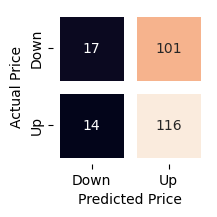

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
#now applying logistic regression
train_and_evaluate(LogisticRegression(max_iter=1000), X, y)

:
Results from algorithm RandomForestClassifier(n_estimators=200, random_state=42):

Accuracy on training data is 1.000

Test data metrics: accuracy=0.544, f1=0.592, precision=0.558,recall=0.631


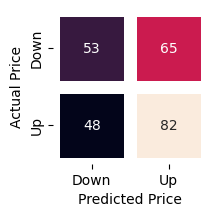

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
#now applying random forest
train_and_evaluate(RandomForestClassifier(n_estimators=200, random_state=42), X, y)

:
Results from algorithm DecisionTreeClassifier():

Accuracy on training data is 1.000

Test data metrics: accuracy=0.516, f1=0.516, precision=0.542,recall=0.492


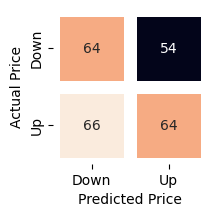

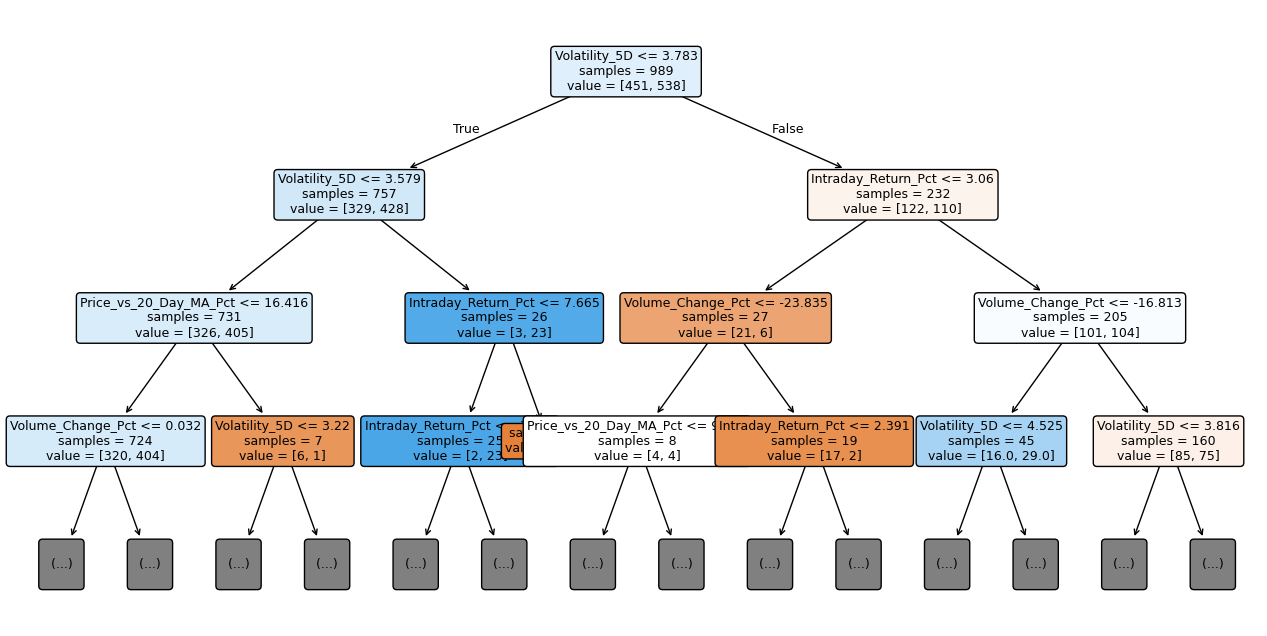

In [37]:
#decision tree 
learnt_model = train_and_evaluate(DecisionTreeClassifier(), X, y)
plt.figure(figsize=(16, 8))
plot_tree(learnt_model, max_depth=3, feature_names=list(X.columns),
fontsize=9, filled=True, impurity=False, rounded=True)
plt.show()

-  weak overall predictive power
-  slight edge for Random Forest
- high recall for Logistic Regression 
- overfitting in tree-based models.



Training set shape: (989, 6)
Test set shape: (248, 6)

Best Logistic Regression parameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best Logistic Regression CV accuracy: 0.541

Best Random Forest parameters: {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 200}
Best Random Forest CV accuracy: 0.532

Results for Tuned Logistic Regression:
Test Accuracy:  0.544
Test Precision: 0.539
Test F1 Score:  0.676
Test Recall:    0.908
Confusion Matrix:
 [[ 17 101]
 [ 12 118]]


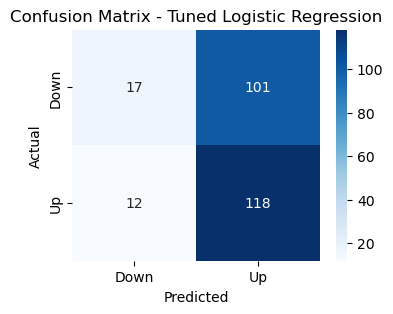


Results for Tuned Random Forest:
Test Accuracy:  0.536
Test Precision: 0.535
Test F1 Score:  0.665
Test Recall:    0.877
Confusion Matrix:
 [[ 19  99]
 [ 16 114]]


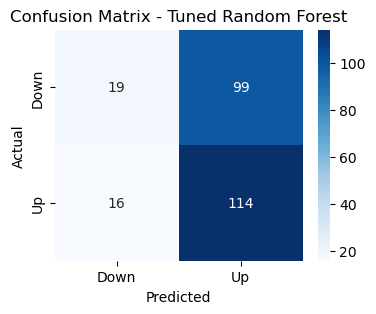

In [38]:
# Selecting the best Hyperparameter values using Time-Aware Hyperparameter Tuning

#recalling the training set 
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training set shape:", X_train_full.shape)
print("Test set shape:", X_test.shape)

#Time aware cross validation on the training set 
tscv = TimeSeriesSplit(n_splits=5)

#Logistic Regression tuning usings scaling because Logistic Regression is scale-sensitive
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))])

log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs"]}


log_search = GridSearchCV(
    estimator=log_pipe,
    param_grid=log_param_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=1)


log_search.fit(X_train_full, y_train_full)

print("\nBest Logistic Regression parameters:", log_search.best_params_)
print("Best Logistic Regression CV accuracy: {:.3f}".format(log_search.best_score_))

# 4. Random Forest tuning

rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]}


rf_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=1)


rf_search.fit(X_train_full, y_train_full)

print("\nBest Random Forest parameters:", rf_search.best_params_)
print("Best Random Forest CV accuracy: {:.3f}".format(rf_search.best_score_))


# 5. Final evaluation function on untouched test set
def evaluate_on_test(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print("\nResults for {}:".format(model_name))
    print("Test Accuracy:  {:.3f}".format(accuracy_score(y_test, y_pred)))
    print("Test Precision: {:.3f}".format(precision_score(y_test, y_pred)))
    print("Test F1 Score:  {:.3f}".format(f1_score(y_test, y_pred)))
    print("Test Recall:    {:.3f}".format(recall_score(y_test, y_pred)))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down', 'Up'],
                yticklabels=['Down', 'Up'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - {}".format(model_name))
    plt.show()

# Evaluate best tuned models on final test set

best_log_model = log_search.best_estimator_
best_rf_model = rf_search.best_estimator_

evaluate_on_test(best_log_model, X_test, y_test, "Tuned Logistic Regression")
evaluate_on_test(best_rf_model, X_test, y_test, "Tuned Random Forest")

Selected and documented model hyperparameters for supervised learning stage include:
-  Logistic Regression (`max_iter`) 
- Random Forest (`n_estimators`, `random_state`)
with notes on time-aware validation considerations for chronological stock data. 

Best Logistic Regression parameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}
Best Logistic Regression CV accuracy: 0.541
Test data metrics: accuracy=0.544, f1=0.676, precision=0.539, recall=0.908
Confusion Matrix:
 [[ 17 101]
 [ 12 118]]


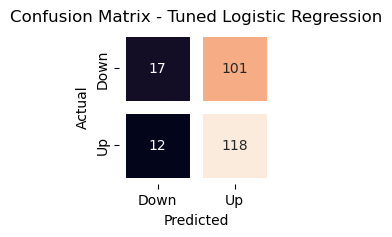

In [39]:
# training both my models again with the best hyperparameter value

# for the best tuned Logistic Regression model
train_accuracy = log_search.best_score_
best_model = log_search.best_estimator_

print("Best Logistic Regression parameters:", log_search.best_params_)
print("Best Logistic Regression CV accuracy: {:.3f}".format(train_accuracy))

y_pred = best_model.predict(X_test)
#checking its accuracy on the untouched data set
print('Test data metrics: accuracy={:.3f}, f1={:.3f}, precision={:.3f}, recall={:.3f}'.format(
    accuracy_score(y_true=y_test, y_pred=y_pred),
    f1_score(y_true=y_test, y_pred=y_pred),
    precision_score(y_true=y_test, y_pred=y_pred),
    recall_score(y_true=y_test, y_pred=y_pred)))

# confusion matrix
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
plt.figure(figsize=(2, 2))
print("Confusion Matrix:\n", cm)
ax = sns.heatmap(cm,annot=True,
                 xticklabels=['Down', 'Up'],
                 yticklabels=['Down', 'Up'],
                 cbar=False,
                 fmt='d', 
                 square=True,
                 linewidths=8.0) # plots the confusion matrix

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

Best Random Forest parameters: {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 200}
Best Random Forest CV accuracy: 0.532
Test data metrics: accuracy=0.536, f1=0.665, precision=0.535, recall=0.877
Confusion Matrix:
 [[ 19  99]
 [ 16 114]]


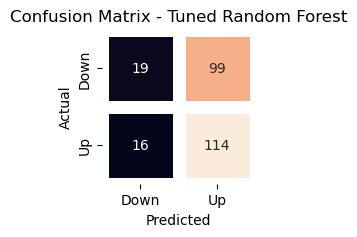

In [40]:
#training my random forest model: 

# Training / evaluating the tuned Random Forest model
train_accuracy = rf_search.best_score_
best_model = rf_search.best_estimator_

print("Best Random Forest parameters:", rf_search.best_params_)
print("Best Random Forest CV accuracy: {:.3f}".format(train_accuracy))

# Predict on the untouched test set
y_pred = best_model.predict(X_test)

print('Test data metrics: accuracy={:.3f}, f1={:.3f}, precision={:.3f}, recall={:.3f}'.format(
    accuracy_score(y_true=y_test, y_pred=y_pred),
    f1_score(y_true=y_test, y_pred=y_pred),
    precision_score(y_true=y_test, y_pred=y_pred),
    recall_score(y_true=y_test, y_pred=y_pred)
))

# Confusion matrix
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(2, 2))
ax = sns.heatmap(
    cm,
    annot=True,
    xticklabels=['Down', 'Up'],
    yticklabels=['Down', 'Up'],
    cbar=False,
    fmt='d', 
    square=True,
    linewidths=8.0
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

### <b>Step 8: PCA Reduction</b>

Does reducing my 6 selected variables into fewer principal components improve, worsen, or leave performance unchanged?

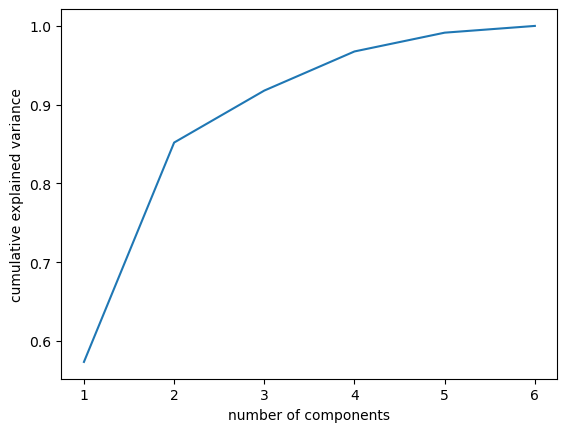

In [41]:

# Using the selected feature matrix X and target y already created earlier
X_pca = X.copy()
y_pca = y.copy()

# Scaling features before PCA 
scaler = MinMaxScaler()
scaler.fit(X_pca)
X_pca = scaler.transform(X_pca)

# Running PCA with the maximum number of components available
# I currently have 6 selected features, so I will use 6 components
pca = PCA(n_components=6).fit(X_pca)

plt.plot(range(1, 7), np.cumsum(pca.explained_variance_ratio_))
plt.xticks(range(1, 7))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

this graph shows the variance in training data accuracy as the number of components increases the variance for better rersults gets closer to 1 which  means more accurate training data accuracy



PCA reduces features from (1237, 6) to (1237, 4)
:
Results from algorithm LogisticRegression(max_iter=1000):

Accuracy on training data is 0.546

Test data metrics: accuracy=0.516, f1=0.672, precision=0.521,recall=0.946


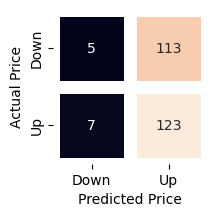

In [42]:
# Testing PCA with 4 components first
pca = PCA(n_components=4).fit(X_pca)
X_reduc = pca.transform(X_pca)

print('\nPCA reduces features from {} to {}'.format(X_pca.shape, X_reduc.shape))

learnt_model = train_and_evaluate(LogisticRegression(max_iter=1000), X_reduc, y_pca)


PCA reduces features from (1237, 6) to (1237, 5)
:
Results from algorithm LogisticRegression(max_iter=1000):

Accuracy on training data is 0.544

Test data metrics: accuracy=0.532, f1=0.676, precision=0.531,recall=0.931


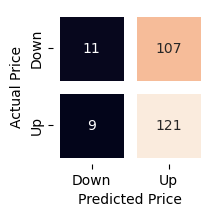

In [43]:
# Try PCA with 5 components
pca = PCA(n_components=5).fit(X_pca)
X_reduc = pca.transform(X_pca)

print('\nPCA reduces features from {} to {}'.format(X_pca.shape, X_reduc.shape))

learnt_model = train_and_evaluate(LogisticRegression(max_iter=1000), X_reduc, y_pca)


PCA reduces features from (1237, 6) to (1237, 6)
:
Results from algorithm LogisticRegression(max_iter=1000):

Accuracy on training data is 0.549

Test data metrics: accuracy=0.532, f1=0.674, precision=0.531,recall=0.923


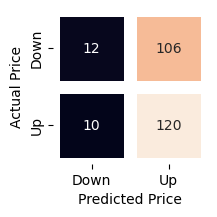

In [44]:
# Try PCA with 6 original components
pca = PCA(n_components=6).fit(X_pca)
X_reduc = pca.transform(X_pca)

print('\nPCA reduces features from {} to {}'.format(X_pca.shape, X_reduc.shape))

learnt_model = train_and_evaluate(LogisticRegression(max_iter=1000), X_reduc, y_pca)

PCA was tested as an optional feature-reduction step, but it did not improve model performance. The highest test accuracy was obtained using all 6 original features, so PCA reduction was not used in the final model.